# MTRN3100 Task 4.2 - Two-Map Planner

This notebook uses **two independent map representations** from one camera image:

1. **Normal maze map:** Task 1's exact `mazemapping/mask_maze.py` processing is converted into a 9 x 9 cell-wall graph and solved before/after the obstacle region. Output is `l`, `r`, and one `f` per 180 mm cell.
2. **Continuous obstacle map:** the configured 5 x 5 region is cropped into a metric occupancy grid and solved with collision-checked RRT*. Output is `(turn angle, distance mm)` tuples.

The stages are: **normal graph -> obstacle RRT* -> normal graph**.

**Generative AI disclosure:** OpenAI Codex assisted with implementation and testing.

In [23]:
from pathlib import Path
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, *working_directory.parents)
    if (candidate / 'computer' / 'task4').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from computer.task4 import ContinuousPlanner
from mazemapping.mask_maze import DARK_THRESHOLD, GAMMA, THIN_LINE_THRESHOLD, create_maze_masks
from mazemappingtask2.task2_pipeline import rectify_course
from mazemappingtask2 import (
    DemoConfig,
    MappingPreview,
    Portal,
    build_normal_maze_map,
    build_obstacle_map,
    default_unavailable_cells,
    draw_coordinate_grid,
    draw_normal_wall_diagnostics,
    make_grid_calibration,
    run_two_map_demo,
)
TASK2_DIR = PROJECT_ROOT / 'mazemappingtask2'

## Phase 1: choose the image and display its coordinate grid

Run the next two cells first. They only rectify and mask the image, so incorrect entrance/exit coordinates cannot stop the preview. Every cell is labelled `row,column`; `(0,0)` is at the top-left.

If the grid lines do not align with the physical 9 x 9 cells, correct `grid_bounds` before choosing coordinates.

In [24]:
IMAGE_FILE = TASK2_DIR / 'maz6.png'  # <-- change the image here
OUTPUT_PIXELS = 324
BOARD_CORNERS = None  # set TL, TR, BR, BL for a new angled camera setup
GRID_BOUNDS = (29.0, 27.0, 299.0, 297.0)

# Use the exact defaults from mazemapping/mask_maze.py. The full-resolution
# source photo is masked first; its completed masks are rectified afterward.
MASK_DARK_THRESHOLD = DARK_THRESHOLD
MASK_THIN_LINE_THRESHOLD = THIN_LINE_THRESHOLD
MASK_GAMMA = GAMMA

preview_config = DemoConfig(
    image_file=IMAGE_FILE,
    output_pixels=OUTPUT_PIXELS,
    board_corners=BOARD_CORNERS,
    grid_bounds=GRID_BOUNDS,
)

## Labelled grid preview

Mask source: mazemapping/mask_maze.py -> create_maze_masks()


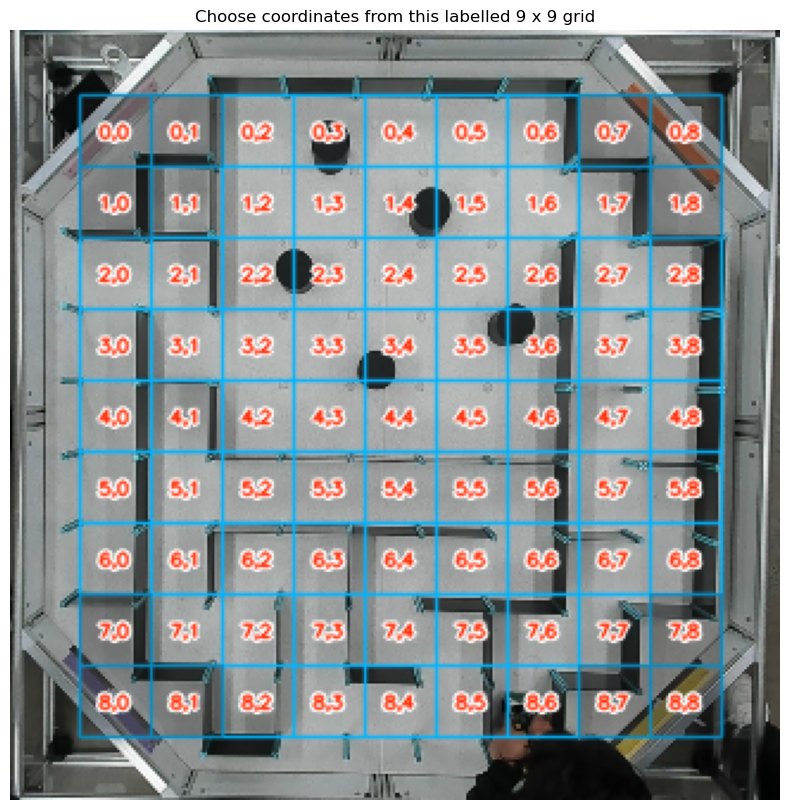

In [25]:
# The notebook's only CV-mask generator: mazemapping/mask_maze.py.
source_bgr = cv2.imread(str(IMAGE_FILE), cv2.IMREAD_COLOR)
if source_bgr is None:
    raise FileNotFoundError(f'Could not load maze image: {IMAGE_FILE}')

# Match running mask_maze.py directly: mask the original-resolution photo.
source_task1_masks = create_maze_masks(
    source_bgr,
    dark_threshold=MASK_DARK_THRESHOLD,
    thin_line_threshold=MASK_THIN_LINE_THRESHOLD,
    gamma=MASK_GAMMA,
)

rectified_bgr = rectify_course(source_bgr, OUTPUT_PIXELS, BOARD_CORNERS)
# Transform the finished Task 1 outputs into planner coordinates. Binary
# masks use nearest-neighbour interpolation so they remain exactly 0/255.
task1_masks = {
    name: rectify_course(
        output,
        OUTPUT_PIXELS,
        BOARD_CORNERS,
        interpolation=cv2.INTER_NEAREST if output.ndim == 2 else cv2.INTER_AREA,
    )
    for name, output in source_task1_masks.items()
}
grid_calibration = make_grid_calibration(*GRID_BOUNDS)
mapping_preview = MappingPreview(
    source_bgr=source_bgr,
    rectified_bgr=rectified_bgr,
    task1_masks=task1_masks,
    calibration=grid_calibration,
    coordinate_grid_bgr=draw_coordinate_grid(rectified_bgr, grid_calibration),
)

print('Mask source: mazemapping/mask_maze.py -> create_maze_masks()')
plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(mapping_preview.coordinate_grid_bgr, cv2.COLOR_BGR2RGB))
plt.title('Choose coordinates from this labelled 9 x 9 grid')
plt.axis('off')
plt.show()

## Phase 2: configure the cells and inspect the cylinder safety map

Staff confirmed the 5 x 5 entrance and exit may be programmed. Enter both sides of each doorway: `inside_cell` must be inside the 5 x 5 obstacle area and `outside_cell` must be the neighbouring normal-maze cell. The two cells must share one side.

The values below are an example for the current `maze2.png`; verify them against the labelled grid. Headings are east `0`, north `90`, west `180`, south `-90`.

In [26]:
OBSTACLE_TOP_LEFT = (0, 2)
OBSTACLE_SIZE = 5

START = (6, 0)
GOAL = (5, 7)
INITIAL_HEADING_DEG = 90.0
GOAL_HEADING_DEG = None

# ENTRANCE_OUTSIDE = (6, 1)
# ENTRANCE_INSIDE = (5, 1)
# EXIT_INSIDE = (1, 5)
# EXIT_OUTSIDE = (0, 5)
EXIT_OUTSIDE = (1, 7)
EXIT_INSIDE = (1, 6)
ENTRANCE_INSIDE = (3, 2)
ENTRANCE_OUTSIDE = (3, 1)

CONFIG = DemoConfig(
    image_file=IMAGE_FILE,
    output_pixels=OUTPUT_PIXELS,
    board_corners=BOARD_CORNERS,
    grid_bounds=GRID_BOUNDS,
    obstacle_top_left=OBSTACLE_TOP_LEFT,
    obstacle_size=OBSTACLE_SIZE,
    entrance=Portal(outside_cell=ENTRANCE_OUTSIDE, inside_cell=ENTRANCE_INSIDE),
    exit=Portal(outside_cell=EXIT_OUTSIDE, inside_cell=EXIT_INSIDE),
    start=START,
    goal=GOAL,
    initial_heading_deg=INITIAL_HEADING_DEG,
    goal_heading_deg=GOAL_HEADING_DEG,
    robot_radius_mm=30.0,  # replace with measured centre-to-furthest-corner
    safety_margin_mm=10.0, # was 5 dddd
    obstacle_resolution_mm=5.0,
    # obstacle_distance_scale=1000.0 / 1018.2,  # measured drive calibration
    obstacle_distance_scale=0.97,
    rrt_max_waypoint_spacing_mm=150.0,  # increase for fewer blue dots; decrease for more
)

## Pre-planning cylinder and safety-buffer check

This cell shows both masks before planning: the full Task 1 wall mask, the normal graph's confidently detected walls, and the filtered cylinder/safety mask used by RRT*. It does **not** run either path search. The wall-decision view draws only blocked walls in red; borderline evidence is treated as open and is not drawn.

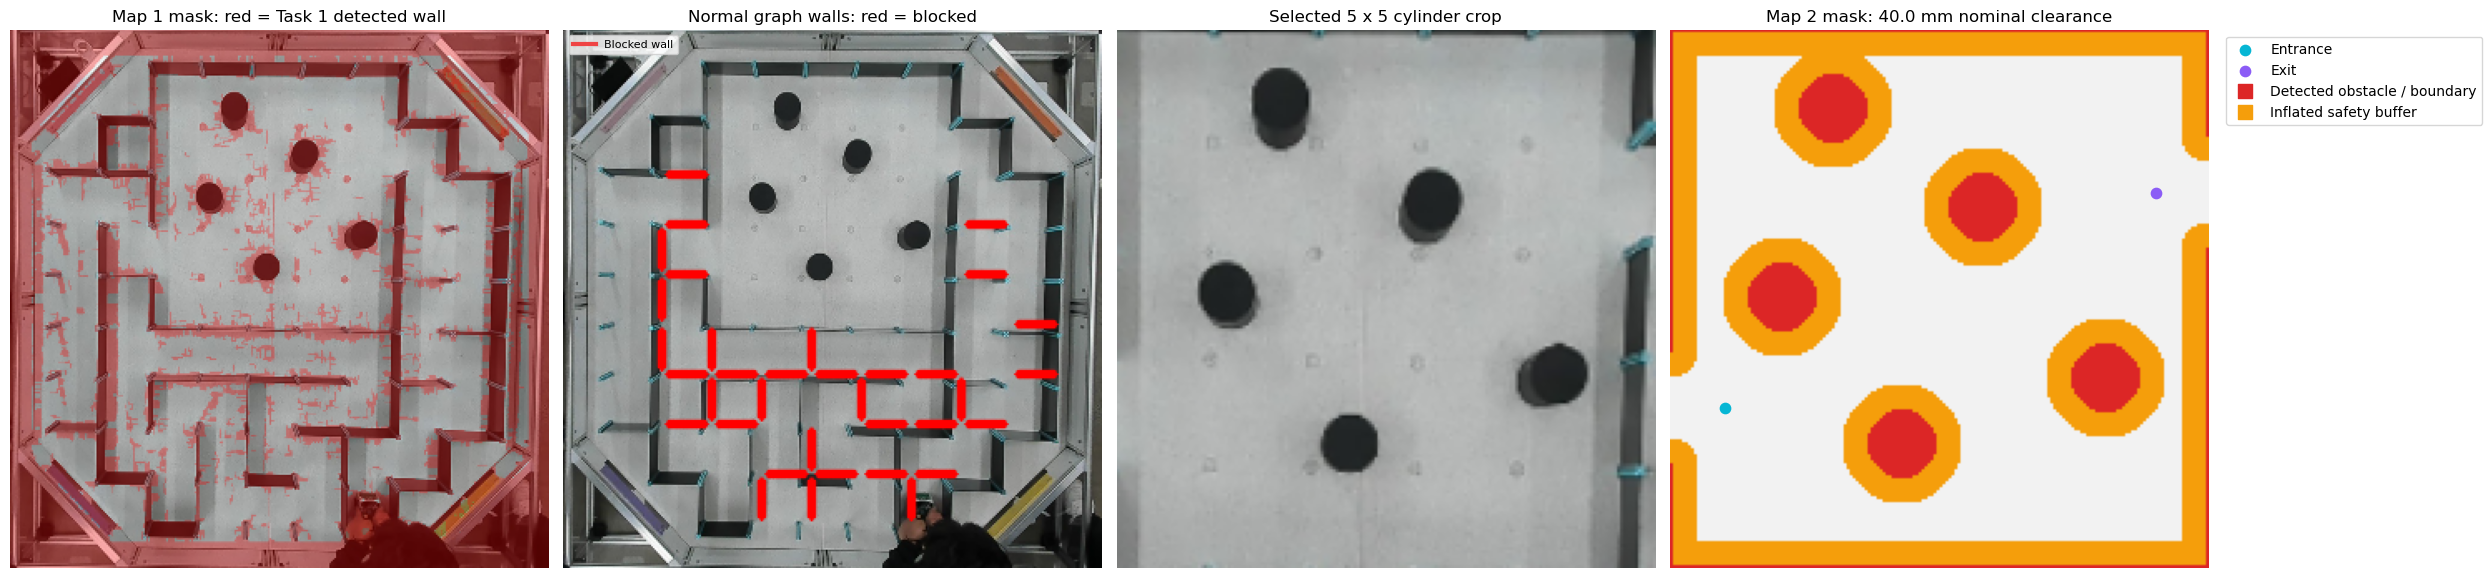

Detected cylinder count: 5
Detected cylinder centres: [(54, 26), (104, 59), (37, 89), (145, 116), (77, 138)]
Robot radius: 30.0 mm
Extra safety margin: 10.0 mm
Total nominal clearance: 40.0 mm


In [27]:
preplan_normal_map = build_normal_maze_map(
    mapping_preview.task1_masks,
    mapping_preview.calibration,
    CONFIG.obstacle_top_left,
    CONFIG.obstacle_size,
    CONFIG.entrance,
    CONFIG.exit,
    unavailable_cells=default_unavailable_cells(),
    endpoint_clearings=(
        (mapping_preview.calibration.centre(CONFIG.start), CONFIG.endpoint_clear_radius_pixels),
        (mapping_preview.calibration.centre(CONFIG.goal), CONFIG.endpoint_clear_radius_pixels),
    ),
)
normal_wall_view = draw_normal_wall_diagnostics(
    mapping_preview.rectified_bgr, preplan_normal_map
)

preplan_obstacle_map = build_obstacle_map(
    mapping_preview.rectified_bgr,
    mapping_preview.task1_masks,
    mapping_preview.calibration,
    CONFIG.obstacle_top_left,
    CONFIG.obstacle_size,
    CONFIG.entrance,
    CONFIG.exit,
    resolution_mm=CONFIG.obstacle_resolution_mm,
)

clearance_mm = CONFIG.robot_radius_mm + CONFIG.safety_margin_mm
# Use the planner's exact inflation operation only; no path search occurs here.
preplan_inflated_grid = ContinuousPlanner._inflate(
    preplan_obstacle_map.grid, clearance_mm
)
raw_obstacles = preplan_obstacle_map.occupancy_mask > 0
inflated_obstacles = np.asarray(preplan_inflated_grid.cells, dtype=bool).reshape(
    preplan_inflated_grid.height, preplan_inflated_grid.width
)
buffer_only = inflated_obstacles & ~raw_obstacles

# RGB diagnostic colours: free=light grey, safety buffer=amber, obstacle=red.
safety_view = np.full((*raw_obstacles.shape, 3), 242, dtype=np.uint8)
safety_view[buffer_only] = (245, 158, 11)
safety_view[raw_obstacles] = (220, 38, 38)

figure, axes = plt.subplots(1, 4, figsize=(25, 7))
axes[0].imshow(cv2.cvtColor(
    mapping_preview.task1_masks['08_mask_overlay.png'],
    cv2.COLOR_BGR2RGB,
))
axes[0].set_title('Map 1 mask: red = Task 1 detected wall')
axes[1].imshow(cv2.cvtColor(normal_wall_view, cv2.COLOR_BGR2RGB))
axes[1].set_title('Normal graph walls: red = blocked')
axes[1].plot([], [], color='#ef4444', linewidth=3, label='Blocked wall')
axes[1].legend(loc='upper left', fontsize=8)
axes[2].imshow(cv2.cvtColor(preplan_obstacle_map.crop_bgr, cv2.COLOR_BGR2RGB))
axes[2].set_title('Selected 5 x 5 cylinder crop')
axes[3].imshow(safety_view)
axes[3].scatter(*preplan_obstacle_map.entrance_local, color='#06b6d4', s=55, label='Entrance')
axes[3].scatter(*preplan_obstacle_map.exit_local, color='#8b5cf6', s=55, label='Exit')
axes[3].scatter([], [], marker='s', s=90, color='#dc2626', label='Detected obstacle / boundary')
axes[3].scatter([], [], marker='s', s=90, color='#f59e0b', label='Inflated safety buffer')
axes[3].set_title(f'Map 2 mask: {clearance_mm:.1f} mm nominal clearance')
axes[3].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

print('Detected cylinder count:', len(preplan_obstacle_map.detected_centres))
print('Detected cylinder centres:', preplan_obstacle_map.detected_centres)
print(f'Robot radius: {CONFIG.robot_radius_mm:.1f} mm')
print(f'Extra safety margin: {CONFIG.safety_margin_mm:.1f} mm')
print(f'Total nominal clearance: {clearance_mm:.1f} mm')

## Phase 3: execute both maps and all three planning stages

In [28]:
# Reuse the exact masks created above; do not reload or remask the photo.
result = run_two_map_demo(CONFIG, preview=mapping_preview)

print('Stage 1 - normal cell graph:', result.route.normal_before_cells)
print('Stage 2 - continuous obstacle RRT*:', result.route.obstacle_result.status.value)
print('Stage 3 - normal cell graph:', result.route.normal_after_cells)
print('Detected obstacle centres in crop:', result.obstacle_map.detected_centres)

RuntimeError: no normal-maze path exists from start to entrance

## Task 1 mask confirmation

This is the overlay returned directly by `mazemapping.mask_maze.create_maze_masks()`. It is shown for verification, but the normal planner samples expected cell boundaries instead of treating the entire red image as a continuous occupancy grid.

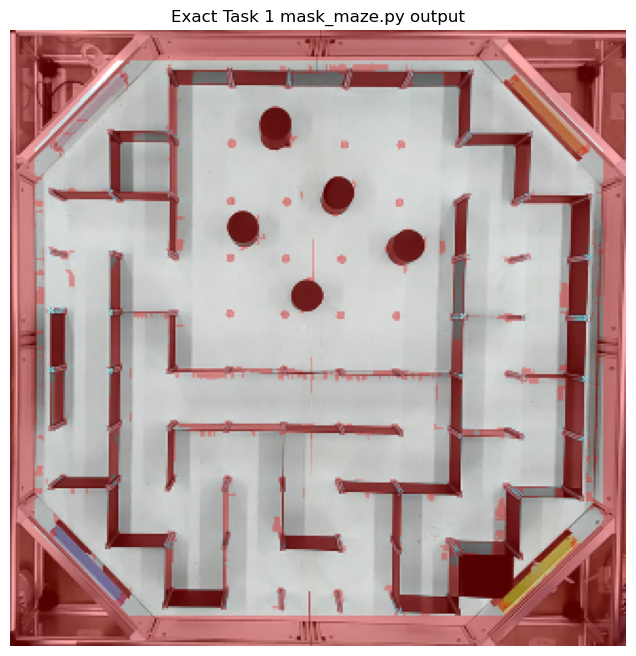

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result.task1_masks['08_mask_overlay.png'], cv2.COLOR_BGR2RGB))
plt.title('Exact Task 1 mask_maze.py output')
plt.axis('off')
plt.show()

## The two independent maps

Left: the normal 9 x 9 cell graph with the 5 x 5 interior excluded except its two portals. Blue and magenta are the normal routes.

Right: only the 5 x 5 continuous crop. Red is detected cylinders/boundary, amber is robot clearance, and green is the RRT* route.

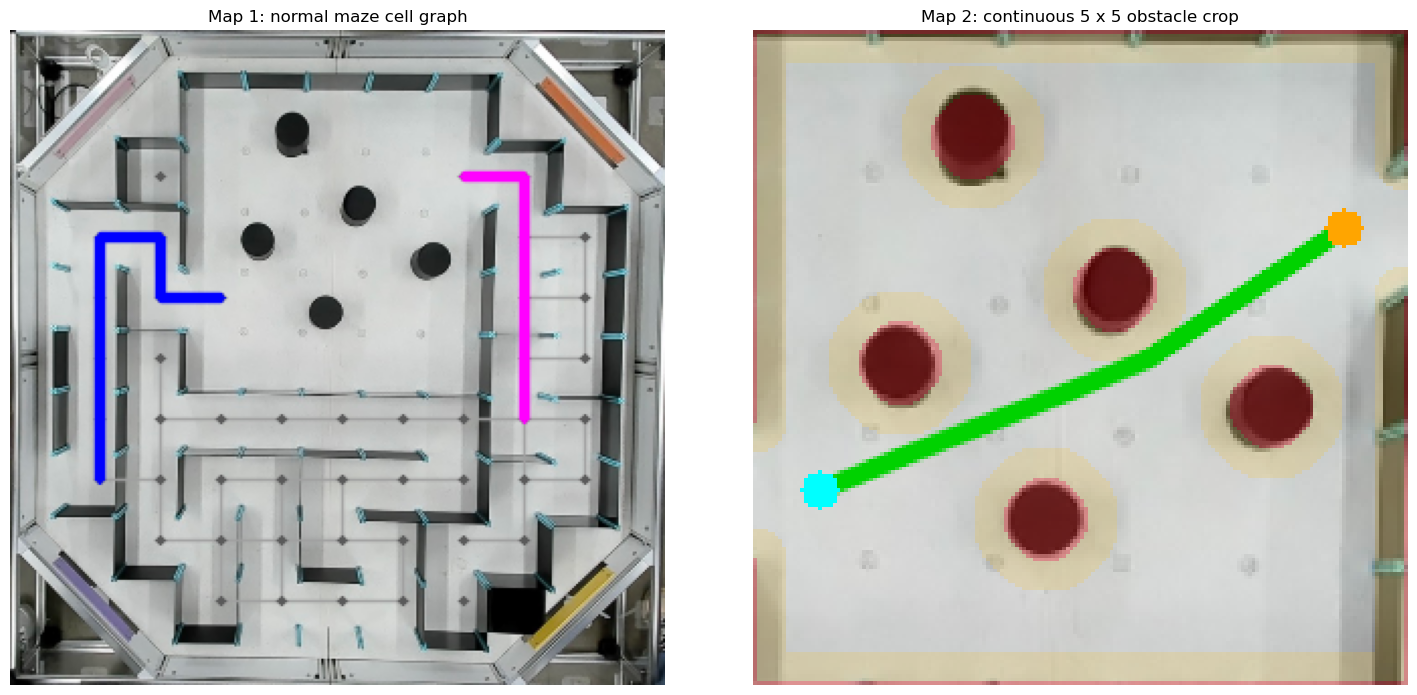

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(cv2.cvtColor(result.normal_preview_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Map 1: normal maze cell graph')
axes[1].imshow(cv2.cvtColor(result.obstacle_preview_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title('Map 2: continuous 5 x 5 obstacle crop')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

## Complete joined path on the original camera image

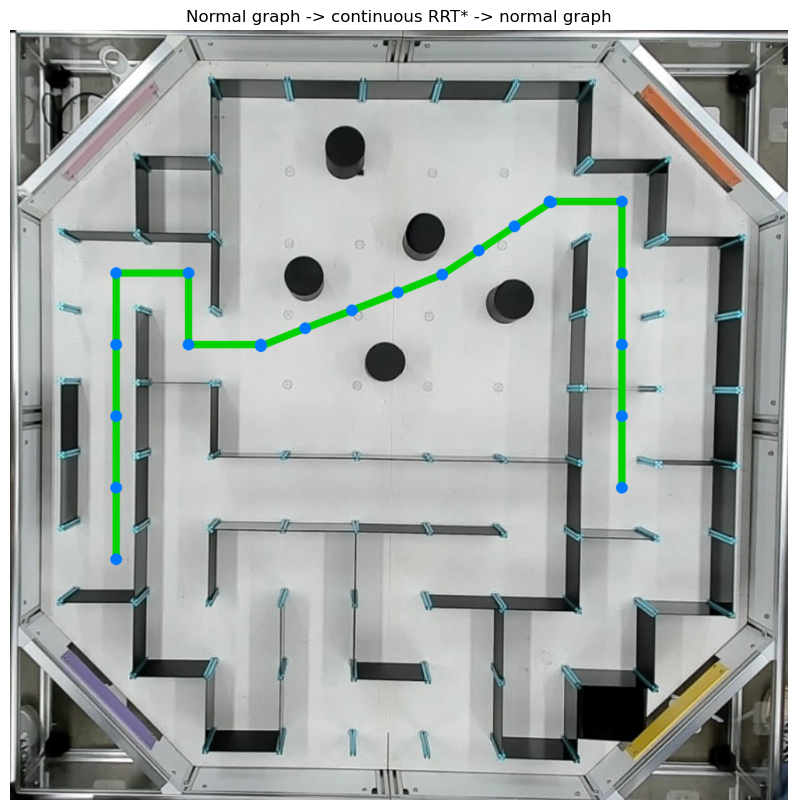

In [ ]:
plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(result.original_preview_bgr, cv2.COLOR_BGR2RGB))
plt.title('Normal graph -> continuous RRT* -> normal graph')
plt.axis('off')
plt.show()

In [ ]:

print(result.route.command)

"ffffrfrflf,[(22.2,115.3),(-0.9,119.8),(0.0,119.8),(0.9,115.3),(11.4,104.9),(0.0,104.9),(0.0,104.9),(-33.7,0.0)],frffff";
